1D Timeseries

predicting multiple feature

Forecasting 1 timestep

Peter Resch, 27.5.

In [2]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np

from sklearn.manifold import TSNE
import seaborn as sns

from sklearn import metrics
import sklearn as sk

import torch as pt

import scipy

rSeed=42

SavePlots = False

## Loading Data

In [5]:
#from https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=download
# ERA5 single levels time series
filename="../common_tryout_datasets/single-point-timeseries_all_vars.nc"

import netCDF4
import xarray as xr

# Open the NetCDF files using xarray
ds = xr.open_dataset(filename)

# Check the available variables
print("data variables:", ds.variables)

data variables: Frozen({'u10': <xarray.Variable (valid_time: 26328)> Size: 105kB
[26328 values with dtype=float32]
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           u10
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               m s**-1
    long_name:                                10 metre U wind component
    standard_name:                            unknown
    units:                                    m s**-1, 'v10': <xarray.Variable (valid_time: 26328)> Size: 105kB
[26328 values with dtype=float32]
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:     

## Prepare Dataset

In [6]:
df=ds.to_dataframe()
df.drop(columns=["longitude","latitude"], inplace=True)


n_input_features=df.shape[1]
print("Number of input features:", n_input_features)

df.head()

Number of input features: 7


,u10,v10,t2m,sp,ssrd,tcc,tp
valid_time,,,,,,,
2023-01-01 00:00:00,0.827942,3.890182,281.892914,99896.132812,0.0,1.0,0.001056
2023-01-01 01:00:00,1.914902,4.523148,282.134155,99824.218750,0.0,1.0,0.001635
2023-01-01 02:00:00,6.367859,5.197357,283.108521,99778.906250,0.0,1.0,0.002318
2023-01-01 03:00:00,7.096558,4.566437,283.962952,99825.796875,0.0,1.0,0.001487
2023-01-01 04:00:00,7.252274,5.145782,284.175415,99825.359375,0.0,1.0,0.000404


In [16]:
dataset=df.values


# Normalize the dataset
scaler = sk.preprocessing.StandardScaler()
dataset = scaler.fit_transform(dataset)#!!!!!!!!!!!!!!!also fitting on future data, but this is just a tryout, so it is not a problem for now. In the final version, only on the training data and transform the validation and validate data using the same scaler.
dataset.shape

(26328, 7)

/tmp/ipykernel_18006/1180550352.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/tmp/ipykernel_18006/1180550352.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


((1053, 24, 7), (1053, 1, 7))

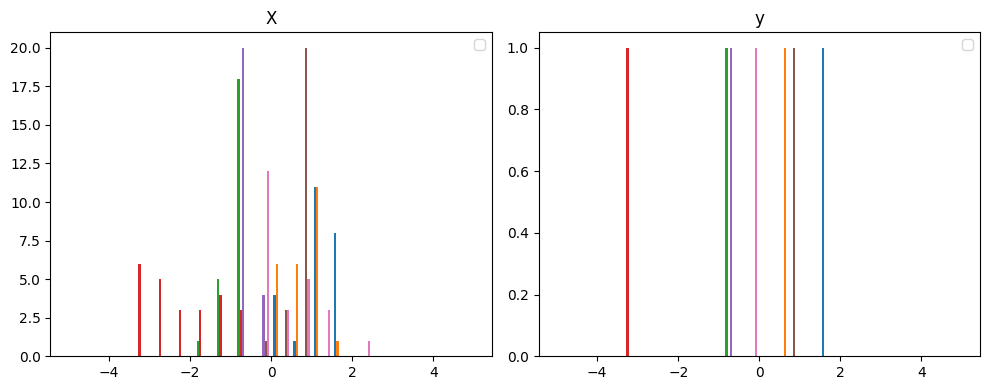

In [19]:
# Split the dataset into input (X) and output (y) variables
forecast_history = 24
forecast_horizon = 1#univariate forecasting, so only t2m is forecasted, but the input can contain multiple features, such as longitude and latitude. In the final version, I will also try multivariate forecasting, where multiple features are forecasted at the same time.
forecast_data_size = forecast_history + forecast_horizon

total_data_len = dataset.shape[0]

X_array = []
y_array = []

for i in range(0, total_data_len-forecast_data_size, forecast_data_size):
    X = dataset[i:i+forecast_history,:]
    y = dataset[i+forecast_history:i+forecast_history+forecast_horizon,:]

    X_array.append(X)
    y_array.append(y)

X_array = np.array(X_array)
y_array = np.array(y_array)

#print(f"i={i}, X={X}, y={y}")
#print(f"X_array: \n{X_array}\n")
#print(f"X_array: \n{X_array[0]}\n")
#print(f"X_array: \n{X_array[0][:,0]}\n")



fig,ax=plt.subplots(1,2,figsize=(10,4))

ax[0].hist(X[:,:], bins=20,range=(-5,5))#,label="t2m",alpha=0.5)
#ax[0].hist(X[:,1], bins=20,range=(-5,5),label="longitude",alpha=0.5)
ax[0].legend()
ax[1].hist(y[:,:], bins=20,range=(-5,5))#,label="t2m",alpha=0.5)
#ax[1].hist(y[:,1], bins=20,range=(-5,5),label="longitude", alpha=0.5)
ax[1].legend()
ax[0].set_title("X")
ax[1].set_title("y")
plt.tight_layout()

X_array.shape, y_array.shape

In [20]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return len(self.input)


#Split the data into training, validateing and testing sets
X_array, X_test, y_array, y_test = train_test_split(X_array, y_array, test_size=0.1, random_state=rSeed)
X_train, X_validate, y_train, y_validate = train_test_split(X_array, y_array, test_size=0.2, random_state=rSeed)
len(X_train),X_train[0].shape,len(X_array),X_array[0].shape

(757, (24, 7), 947, (24, 7))

In [21]:
def make_loader(X, y,batch_size):
    X_tensor=torch.FloatTensor(np.array(X))
    print(f"X_tensor shape: {X_tensor.shape}")
    y_tensor=torch.FloatTensor(np.array(y))
    set = MyDataset(X_tensor, y_tensor)
    loader = DataLoader(set, batch_size=batch_size)
    return loader


trainloader = make_loader(X_train, y_train, batch_size=200)
validateloader = make_loader(X_validate, y_validate, batch_size=200)
testloader = make_loader(X_test, y_test, batch_size=200)

X_tensor shape: torch.Size([757, 24, 7])
X_tensor shape: torch.Size([190, 24, 7])
X_tensor shape: torch.Size([106, 24, 7])


In [23]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

hidden_size=16

class myGRU(nn.Module):
    def __init__(self,hidden_size=hidden_size):
        super().__init__()
        self.gru = nn.GRU(input_size=n_input_features,hidden_size=hidden_size, num_layers=1,dropout=0,batch_first=True)
        self.linear = nn.Linear(hidden_size, n_input_features) # univariate output, so output size is 1

    def forward(self, x):
        #print("in NeuralNetwork.forward")
        #print(x.shape)
        x,y = self.gru(x)
        #print(x.shape,y.shape)
        x = x[:,-1,:].view(x.shape[0], 1,x.shape[2])#last hidden state
        #print(x.shape)
        x=self.linear(x)
        #print(x.shape)
        return x

class myLSTM(nn.Module):
    def __init__(self,hidden_size=hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_input_features,hidden_size=hidden_size, num_layers=1,dropout=0,batch_first=True)
        self.linear = nn.Linear(hidden_size, n_input_features) # univariate output, so output size is 1

    def forward(self, x):
        #print("in NeuralNetwork.forward")
        #print(x.shape)
        x,y = self.lstm(x)
        #print(x.shape,y.shape)
        x = x[:,-1,:].view(x.shape[0], 1,x.shape[2])#last hidden state
        #print(x.shape)
        x=self.linear(x)
        #print(x.shape)
        return x



gru_model=myGRU().to(device)
print(gru_model)

lstm_model=myLSTM().to(device)
print(lstm_model)

# Loss function and optimizer
loss_fcn = nn.MSELoss()
optimizer_gru = AdamW(gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer_lstm = AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)

Using cpu device
myGRU(
  (gru): GRU(7, 16, batch_first=True)
  (linear): Linear(in_features=16, out_features=7, bias=True)
)
myLSTM(
  (lstm): LSTM(7, 16, batch_first=True)
  (linear): Linear(in_features=16, out_features=7, bias=True)
)


In [ ]:
def train(dataloader, model, loss_fn, optimizer,device):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        #print(X.shape, y.shape)
        X, y = X.to(device), y.to(device)
        #print(X.shape, y.shape)

        # Compute prediction error
        pred = model(X)#.squeeze()
        #print(pred)#.shape)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test_classification(dataloader, model, loss_fn, device):#not used here
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    validate_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            validate_loss += loss_fn(logits, y).item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            correct += (preds == y).float().sum().item()
    validate_loss /= num_batches
    correct /= size
    print(f"validate Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {validate_loss:>8f} \n")



def test(dataloader, model, loss_fn,device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            predictions = model(X)
            test_loss += loss_fn(predictions, y).item()

            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    test_loss /= num_batches
    y_pred = np.concatenate(all_predictions)#[:,:,0]
    y_true = np.concatenate(all_targets)#[:,:,0]
    print(f"y_true shape: {y_true.shape}, y_pred shape: {y_pred.shape}")


    #---------make a for loop for every variable, and print the metrics for each variable separately. For now, I will just print the metrics for the first variable, which is t2m. In the final version, I will also print the metrics for the other variables, such as longitude and latitude.
    
    mae = metrics.mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    r2 = metrics.r2_score(y_true, y_pred)
    print(f"Test Error:\n MAE: {mae:>8f}, RMSE: {rmse:>8f}, R2: {r2:>8f}, Avg loss: {test_loss:>8f} \n")
    return test_loss


In [32]:
test(validateloader, lstm_model, loss_fcn,device)

y_true shape: (190, 1, 7), y_pred shape: (190, 1, 7)


ValueError: Found array with dim 3, while dim <= 2 is required.

In [26]:
trainloader.dataset.input.shape, trainloader.dataset.truth.shape

(torch.Size([757, 24, 7]), torch.Size([757, 1, 7]))

In [27]:
epochs = 2
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainloader, lstm_model, loss_fcn, optimizer_lstm,device)
    test(validateloader, lstm_model, loss_fcn,device)
print("Done!")

Epoch 1
-------------------------------
loss: 0.926001  [  200/  757]
y_true shape: (190, 1), y_pred shape: (190, 1)
Test Error:
 MAE: 0.829208, RMSE: 1.029237, R2: -0.073549, Avg loss: 1.079024 

Epoch 2
-------------------------------
loss: 0.910974  [  200/  757]
y_true shape: (190, 1), y_pred shape: (190, 1)
Test Error:
 MAE: 0.820277, RMSE: 1.017431, R2: -0.049062, Avg loss: 1.064371 

Done!


In [28]:
epochs = 2
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainloader, gru_model, loss_fcn, optimizer_gru,device)
    test(validateloader, gru_model, loss_fcn,device)
print("Done!")

Epoch 1
-------------------------------
loss: 0.995242  [  200/  757]
y_true shape: (190, 1), y_pred shape: (190, 1)
Test Error:
 MAE: 0.816588, RMSE: 0.987756, R2: 0.011240, Avg loss: 1.144818 

Epoch 2
-------------------------------
loss: 0.961857  [  200/  757]
y_true shape: (190, 1), y_pred shape: (190, 1)
Test Error:
 MAE: 0.801972, RMSE: 0.970255, R2: 0.045968, Avg loss: 1.111269 

Done!


## Tryout Section - just for trying stuff